# Stage 1: PubMedQA Data Exploration


## Dataset Schema (PubMedQA)

- `question`: the biomedical research question to be answered (`yes`/`no`/`maybe`).
- `context`: evidence bundle (dictionary), mainly `contexts` (text snippets), plus metadata such as `labels` and `meshes`.
- `long_answer`: a free-text explanatory answer based on the evidence.
- `final_decision` (labeled split only): the final short target label (`yes`, `no`, or `maybe`).

In this project, tokenization-sensitive analysis focuses mostly on `context` text because it is much longer and lexically richer than `question`.


In [9]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer


In [10]:
def get_context_text(context_field):
    if isinstance(context_field, dict):
        contexts = context_field.get("contexts", [])
        if isinstance(contexts, list):
            return " ".join(str(part) for part in contexts)
    if isinstance(context_field, list):
        return " ".join(str(part) for part in context_field)
    return str(context_field)


def count_words(text):
    return len(str(text).split())


def flatten_tokens(text_series):
    for text in text_series.fillna(""):
        for tok in re.findall(r"[A-Za-z][A-Za-z\-]+", text.lower()):
            yield tok


## Step 1. Load Dataset and Build Analysis Tables


In [11]:
labeled = load_dataset("qiaojin/PubMedQA", "pqa_labeled")["train"]
unlabeled = load_dataset("qiaojin/PubMedQA", "pqa_unlabeled")["train"]

df_labeled = pd.DataFrame({
    "question": labeled["question"],
    "context_text": [get_context_text(ctx) for ctx in labeled["context"]],
    "label": labeled["final_decision"],
})

df_unlabeled = pd.DataFrame({
    "question": unlabeled["question"],
    "context_text": [get_context_text(ctx) for ctx in unlabeled["context"]],
})

for frame in (df_labeled, df_unlabeled):
    frame["question_word_count"] = frame["question"].map(count_words)
    frame["context_word_count"] = frame["context_text"].map(count_words)

print("Labeled samples:", len(df_labeled))
print("Unlabeled samples:", len(df_unlabeled))
print("\nLabeled columns:", list(df_labeled.columns))
print("Unlabeled columns:", list(df_unlabeled.columns))

display(df_labeled.head(3))


Labeled samples: 1000
Unlabeled samples: 61249

Labeled columns: ['question', 'context_text', 'label', 'question_word_count', 'context_word_count']
Unlabeled columns: ['question', 'context_text', 'question_word_count', 'context_word_count']


,question,context_text,label,question_word_count,context_word_count
0,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,yes,14,251
1,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,no,10,245
2,"Syncope during bathing in infants, a pediatric...",Apparent life-threatening events in infants ar...,yes,11,173


### Step 1 Conclusion

- The loaded data contains **1,000 labeled** samples and **61,249 unlabeled** samples.
- This gives a small supervised set for controlled evaluation and a large in-domain corpus for vocabulary statistics.
- The schema is consistent (`question`, `context_text`, and optional `label`), so downstream tokenization analysis is reliable.


## Step 2. Label Distribution (Class Balance)


,count,share_percent
label,,
yes,552,55.2
no,338,33.8
maybe,110,11.0


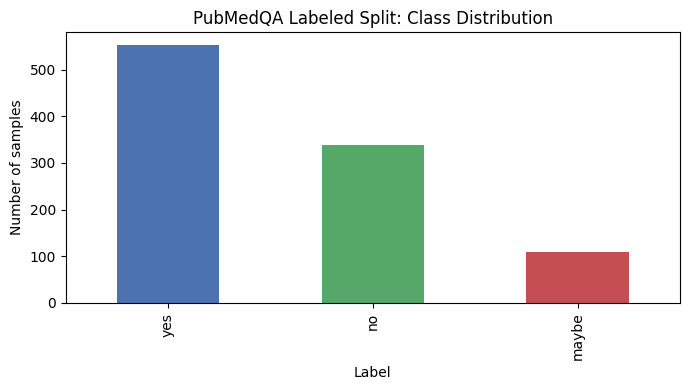

In [12]:
label_counts = df_labeled["label"].value_counts().sort_values(ascending=False)
label_share = (label_counts / label_counts.sum() * 100).round(2)

label_stats = pd.DataFrame({
    "count": label_counts,
    "share_percent": label_share,
})

display(label_stats)

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("PubMedQA Labeled Split: Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()


### Step 2 Conclusion

- The labeled split is imbalanced: **yes = 55.2% (552)**, **no = 33.8% (338)**, **maybe = 11.0% (110)**.
- The minority `maybe` class is 5x smaller than `yes`, so class imbalance can hide tokenizer effects in classification metrics.
- For fair tokenizer comparison, report macro metrics (not only accuracy).


## Step 3. Length Analysis (Questions vs Contexts)


,question_words,context_words
mean,12.91,200.21
median,13.00,200.50
std,4.10,51.85
p90,18.00,264.00
p95,21.00,287.05
max,31.00,398.00


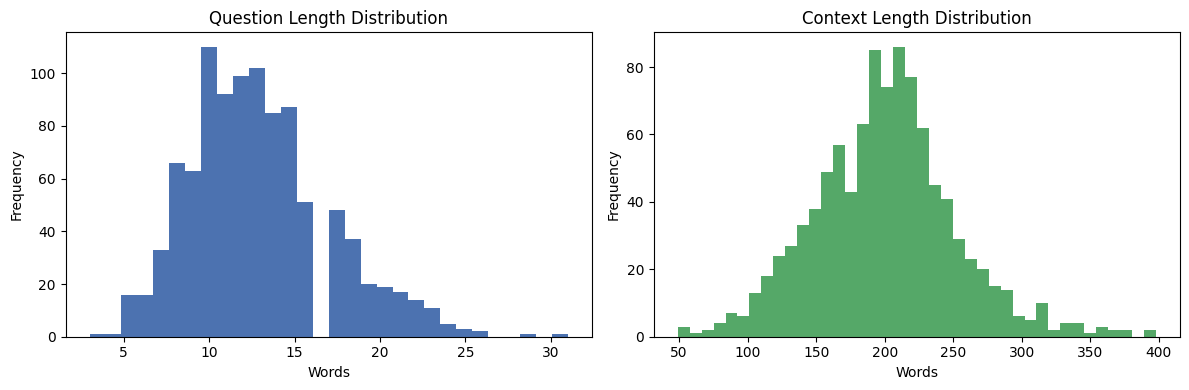

In [13]:
def describe_lengths(series):
    return pd.Series({
        "mean": round(series.mean(), 2),
        "median": round(series.median(), 2),
        "std": round(series.std(), 2),
        "p90": round(series.quantile(0.90), 2),
        "p95": round(series.quantile(0.95), 2),
        "max": int(series.max()),
    })

length_summary = pd.DataFrame({
    "question_words": describe_lengths(df_labeled["question_word_count"]),
    "context_words": describe_lengths(df_labeled["context_word_count"]),
})

display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_labeled["question_word_count"], bins=30, color="#4C72B0")
axes[0].set_title("Question Length Distribution")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_labeled["context_word_count"], bins=40, color="#55A868")
axes[1].set_title("Context Length Distribution")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### Step 3 Conclusion

- Questions are short: mean **12.91** words (p95 = **21**).
- Contexts are long: mean **200.21** words (p95 = **287.05**, max = **398**).
- Contexts are ~15.5x longer than questions on average, so most tokenization cost and fragmentation risk comes from context text.


## Step 4. Lexical Diversity and Frequent Terms


In [14]:
question_tokens = list(flatten_tokens(df_labeled["question"]))
context_tokens = list(flatten_tokens(df_labeled["context_text"]))

def ttr(tokens):
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)

lexical_stats = pd.DataFrame([
    {
        "text_part": "questions",
        "total_tokens": len(question_tokens),
        "unique_tokens": len(set(question_tokens)),
        "type_token_ratio": round(ttr(question_tokens), 4),
    },
    {
        "text_part": "contexts",
        "total_tokens": len(context_tokens),
        "unique_tokens": len(set(context_tokens)),
        "type_token_ratio": round(ttr(context_tokens), 4),
    },
])

display(lexical_stats)

common_context_terms = pd.DataFrame(Counter(context_tokens).most_common(25), columns=["term", "count"])
display(common_context_terms)


,text_part,total_tokens,unique_tokens,type_token_ratio
0,questions,12600,3785,0.3004
1,contexts,180817,13603,0.0752


,term,count
0,the,9285
1,of,7738
2,and,7083
3,in,4942
4,to,3835
5,were,3023
6,with,2972
7,was,2902
8,patients,2421
9,for,2176


### Step 4 Conclusion

- Questions: **12,600** tokens, **3,785** unique, TTR = **0.3004**.
- Contexts: **180,817** tokens, **13,603** unique, TTR = **0.0752**.
- Despite lower context TTR (expected for larger corpora), the context vocabulary is broad in absolute size, supporting the need for robust domain token coverage.


## Step 5. Domain-Specific Signals: Long Terms and Abbreviations


In [15]:
long_term_pattern = re.compile(r"\b[A-Za-z][A-Za-z\-]{11,}\b")
abbrev_pattern = re.compile(r"\b[A-Z]{2,}\b")

all_contexts = df_labeled["context_text"].fillna("")

long_terms = []
abbrev_terms = []
for text in all_contexts:
    long_terms.extend([m.lower() for m in long_term_pattern.findall(text)])
    abbrev_terms.extend(abbrev_pattern.findall(text))

long_terms_df = pd.DataFrame(Counter(long_terms).most_common(25), columns=["long_term", "count"])
abbrev_df = pd.DataFrame(Counter(abbrev_terms).most_common(25), columns=["abbreviation", "count"])

stats = {
    "contexts_with_long_terms_share": round((all_contexts.str.contains(long_term_pattern).mean() * 100), 2),
    "contexts_with_abbreviations_share": round((all_contexts.str.contains(abbrev_pattern).mean() * 100), 2),
}

print("Domain signal coverage (% of contexts):", stats)
print("\nTop long biomedical-like terms:")
display(long_terms_df)
print("Top abbreviations:")
display(abbrev_df)


Domain signal coverage (% of contexts): {'contexts_with_long_terms_share': np.float64(99.8), 'contexts_with_abbreviations_share': np.float64(79.4)}

Top long biomedical-like terms:


,long_term,count
0,significantly,399
1,respectively,224
2,postoperative,143
3,statistically,134
4,retrospective,127
5,participants,126
6,complications,120
7,relationship,107
8,questionnaire,90
9,multivariate,84


Top abbreviations:


,abbreviation,count
0,CI,360
1,OR,168
2,CT,89
3,BMI,70
4,II,68
5,III,67
6,HR,61
7,HIV,54
8,SD,53
9,IV,49


### Step 5 Conclusion

- **99.8%** of contexts include long terms (12+ chars), and **79.4%** include all-caps abbreviations.
- Frequent long terms include `significantly`, `postoperative`, `retrospective`, and `multivariate`.
- Frequent abbreviations include `CI`, `OR`, `CT`, `BMI`, and `HIV`.
- This confirms that biomedical text contains many tokenization-sensitive patterns (long morphology + abbreviations).


## Step 6. Rare Vocabulary Burden (Tokenizer Stress Test)


In [16]:
context_tokens = list(flatten_tokens(df_labeled["context_text"]))
context_freq = Counter(context_tokens)

rare_exact1 = sum(1 for tok in context_tokens if context_freq[tok] == 1)
rare_le3 = sum(1 for tok in context_tokens if context_freq[tok] <= 3)

rare_stats = pd.DataFrame({
    "metric": ["rare_tokens_freq_eq_1", "rare_tokens_freq_le_3"],
    "share_percent": [
        round(rare_exact1 / len(context_tokens) * 100, 2),
        round(rare_le3 / len(context_tokens) * 100, 2),
    ],
})

display(rare_stats)


,metric,share_percent
0,rare_tokens_freq_eq_1,2.84
1,rare_tokens_freq_le_3,7.27


### Step 6 Conclusion

- **2.84%** of context tokens are hapax (frequency = 1).
- **7.27%** of context tokens occur at most 3 times.
- This long tail is exactly where generic tokenizers tend to over-fragment; domain-specific vocabularies should reduce this risk.


## Final EDA Summary for Tokenization Stage

- PubMedQA combines a small labeled set (1,000) with a large in-domain unlabeled corpus (61,249), enabling both supervised and corpus-level tokenization analysis.
- The target labels are imbalanced (`yes` dominates, `maybe` is rare), so tokenizer comparisons should include class-robust metrics.
- Contexts are very long (mean 200.21 words), making context tokenization quality more important than question tokenization.
- Domain signals are strong: almost all contexts contain long terms and most contain abbreviations.
- The corpus includes a measurable rare-token tail, which motivates specialized biomedical subword vocabularies.
